# Reordering and Reorienting One Assembly to Match Another

A freshly assembled genome rarely comes out tidy: contigs are emitted in an
arbitrary order, and roughly half of them are written on the opposite strand to
the reference you want to compare against.  The resulting dotplot is a mess of
off-diagonal blocks and anti-diagonal (reverse-strand) lines that is hard to
interpret.

This tutorial walks through cleaning that up with `CrossIndex`:

1. Load a **reference** and a scrambled **draft** assembly into one `CrossIndex`
   (one group each).
2. Compute cross-group k-mer matches and plot the messy baseline dotplot.
3. Call `reorder_for_colinearity('draft', 'ref', reorder_target=False)` to sort
   the draft contigs along the reference and detect reverse-oriented ones.
4. Re-plot with `reverse_contigs=` to see the clean, near-diagonal layout.
5. Export the corrected draft as a FASTA file with `write_fasta` — contigs
   written in the new order, with reversed contigs reverse-complemented.

> **Orientation is relative.** A contig is only "reversed" *with respect to a
> reference*.  Here the reference (`'ref'` group) is the fixed forward frame:
> its contigs never move or flip; only the draft is reordered and reoriented.

## 1. Build two toy assemblies

The **reference** has three chromosomes of random (non-repetitive) DNA.  The
**draft** contains the same sequence content, but scrambled the way a real
assembler might leave it:

- `chr1` is split into two contigs, and the second piece is
  **reverse-complemented**;
- `chr2` comes back as a single **reverse-complemented** contig;
- `chr3` is intact and forward;
- the contig names (`tig...`) carry no hint of where anything belongs.

In [1]:
import random
import tempfile
from pathlib import Path

from rusty_dot.paf_io import CrossIndex, reverse_complement


def random_dna(length, seed):
    rng = random.Random(seed)
    return ''.join(rng.choice('ACGT') for _ in range(length))


# Reference assembly: three chromosomes.
chr1 = random_dna(500, seed=11)
chr2 = random_dna(400, seed=22)
chr3 = random_dna(300, seed=33)

reference = {'chr1': chr1, 'chr2': chr2, 'chr3': chr3}

# Draft assembly: same content, shuffled and partly reverse-oriented.
draft = {
    'tig1': chr3,                            # chr3, forward
    'tig2': reverse_complement(chr1[250:]),  # second half of chr1, REVERSED
    'tig3': reverse_complement(chr2),        # chr2, REVERSED
    'tig4': chr1[:250],                      # first half of chr1, forward
}

print('Reference order:', list(reference))
print('Draft order    :', list(draft))

Reference order: ['chr1', 'chr2', 'chr3']
Draft order    : ['tig1', 'tig2', 'tig3', 'tig4']


## 2. Load both assemblies into a `CrossIndex`

Each assembly goes into its own group (`'ref'` and `'draft'`).  With real data
you would call `cross.load_fasta('reference.fasta', group='ref')` and
`cross.load_fasta('draft.fasta', group='draft')` instead of `add_sequence`.

In [2]:
cross = CrossIndex(k=13)

for name, seq in reference.items():
    cross.add_sequence(name, seq, group='ref')

for name, seq in draft.items():
    cross.add_sequence(name, seq, group='draft')

print(cross)

CrossIndex (k=13)
  Total sequences : 7
  Group 'ref'       :      3 sequences
  Group 'draft'     :      4 sequences
  Computed pairs  : none (call compute_matches() first)
  PAF records     : 0


## 3. Compute matches and plot the messy baseline

`compute_matches()` is the explicit step that computes and caches cross-group
k-mer matches — it is required before reordering.  We compute the
`('draft', 'ref')` pair: the draft is the **query** (rows) and the reference is
the **target** (columns), i.e. the reference is the fixed frame the draft will
be aligned to.

The baseline many-vs-many dotplot shows the problem: matches are scattered
across off-diagonal panels, and the reverse-oriented contigs (`tig2`, `tig3`)
appear as red anti-diagonal lines.

> **Plotting note.** We pass explicit name lists via
> `cross.sequence_names(group=...)` — the documented way to hand a
> `CrossIndex` group to `DotPlotter` — rather than the `query_group=` /
> `target_group=` shortcut.  The name-list path renders from the stranded
> k-mer engine, so **reverse-strand matches are drawn (in red)**; the group
> shortcut renders from the `compute_matches()` cache, which stores
> forward-strand matches only, so reverse-oriented contigs would show empty
> panels.  The lists come back in the group's current `contig_order`.

Computed group pairs: [('draft', 'ref')]


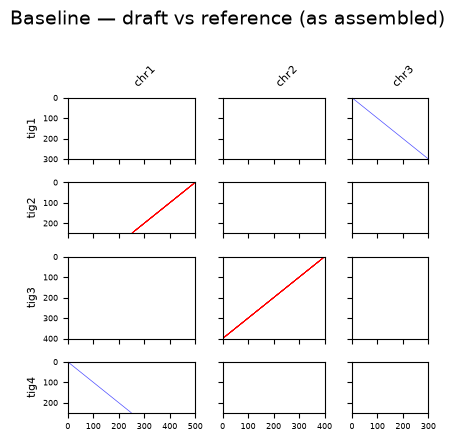

In [3]:
from rusty_dot.dotplot import DotPlotter

cross.compute_matches(query_group='draft', target_group='ref')
print('Computed group pairs:', cross.computed_group_pairs)

plotter = DotPlotter(cross)

fig = plotter.plot(
    query_names=cross.sequence_names(group='draft'),
    target_names=cross.sequence_names(group='ref'),
    figsize_per_panel=1.8,
    scale_sequences=True,
    title='Baseline — draft vs reference (as assembled)',
    dpi=80,
)

Reading this grid: `tig4` and `tig2` both hit `chr1` (`tig4` forward in blue,
`tig2` as a red reverse-strand anti-diagonal), `tig3` hits `chr2` on the
reverse strand (red), and `tig1` hits `chr3` forward — but nothing lines up
along the main diagonal of the grid.

## 4. Reorder and reorient the draft against the reference

`reorder_for_colinearity(query_group, target_group, reorder_target=False)` uses
the d-genies gravity algorithm: each draft contig is assigned to its
best-matching reference chromosome, ordered by its gravity centre there, and
flagged if it aligns predominantly on the reverse strand.

Passing `reorder_target=False` keeps the reference group's order **fixed** —
exactly what you want when aligning a draft to an established reference.  The
new order is stored in `contig_order` and the flagged contigs are available via
`reversed_contigs('draft')`.

In [4]:
cross.reorder_for_colinearity('draft', 'ref', reorder_target=False)

print('Reference order (unchanged):', cross.contig_order['ref'])
print('Draft order (optimised)    :', cross.contig_order['draft'])
print('Draft reverse-oriented     :', sorted(cross.reversed_contigs('draft')))

Reference order (unchanged): ['chr1', 'chr2', 'chr3']
Draft order (optimised)    : ['tig4', 'tig2', 'tig3', 'tig1']
Draft reverse-oriented     : ['tig2', 'tig3']


The draft now mirrors the reference: the two `chr1` pieces come first (`tig4`
then `tig2`, matching their positions along `chr1`), followed by the `chr2`
contig (`tig3`) and the `chr3` contig (`tig1`).  `tig2` and `tig3` are
correctly detected as reverse-oriented.

## 5. Re-plot: the clean, near-diagonal picture

`cross.sequence_names(group='draft')` now returns the internal names in the
**optimised** `contig_order`, so the draft rows follow the new layout
automatically.  Passing the detected set as `reverse_contigs=` renders those
contigs reverse-complemented, so their matches read along the **main
diagonal** (in blue) instead of the red anti-diagonal.  The underlying
coordinates are never modified — only the rendering.

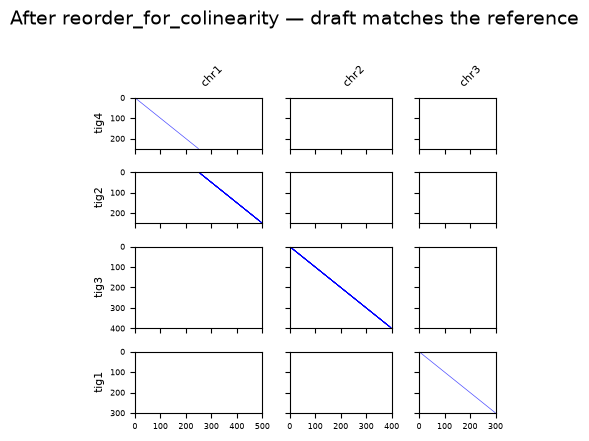

In [5]:
fig = plotter.plot(
    query_names=cross.sequence_names(group='draft'),
    target_names=cross.sequence_names(group='ref'),
    figsize_per_panel=1.8,
    scale_sequences=True,
    title='After reorder_for_colinearity — draft matches the reference',
    dpi=80,
    reverse_contigs=cross.reversed_contigs('draft'),
)

All matches now sit on the main diagonal of the grid, and the previously red
anti-diagonal lines are rendered forward (blue): the draft reads like the
reference, top-left to bottom-right.

## 6. Export the corrected draft as FASTA

`write_fasta(path, group)` persists this layout: contigs are written in the
group's current `contig_order`, and every contig in `reversed_contigs(group)` is
reverse-complemented so it reads forward.  Flipped records carry a
`reverse_complement` note in their header.

In [6]:
outdir = Path(tempfile.mkdtemp())
out_fasta = outdir / 'draft_corrected.fasta'

cross.write_fasta(out_fasta, group='draft')

print('--- draft_corrected.fasta headers (in file order) ---')
for line in out_fasta.read_text().splitlines():
    if line.startswith('>'):
        print(line)

--- draft_corrected.fasta headers (in file order) ---
>tig4
>tig2 reverse_complement
>tig3 reverse_complement
>tig1


The headers confirm the new contig order, and `tig2` / `tig3` are marked as
reverse-complemented.  A quick check that the flipped sequences now equal the
forward reference:

In [7]:
written = {}
for block in out_fasta.read_text().split('>'):
    if not block.strip():
        continue
    header, *seq_lines = block.splitlines()
    written[header.split()[0]] = ''.join(seq_lines)

assert written['tig2'] == chr1[250:]  # flipped back to forward chr1 second half
assert written['tig3'] == chr2        # flipped back to forward chr2
assert written['tig4'] == chr1[:250]  # untouched
assert written['tig1'] == chr3        # untouched
print('All draft contigs now read in the forward reference orientation.')

All draft contigs now read in the forward reference orientation.


## Summary

- Load two assemblies into one `CrossIndex` (groups `'ref'` and `'draft'`),
  then `compute_matches()` for the pair.
- `reorder_for_colinearity('draft', 'ref', reorder_target=False)` sorts the
  draft along the fixed reference and flags reverse-oriented contigs
  (`reversed_contigs('draft')`).
- `DotPlotter.plot(..., reverse_contigs=...)` renders the flagged contigs
  flipped, turning the messy baseline into a near-diagonal plot.
- `write_fasta(path, group='draft')` exports the corrected assembly: reordered,
  with reversed contigs reverse-complemented.

## Related tutorials

- [All-vs-All Between Two Indices](all_vs_all_two_indices.ipynb) — the
  `CrossIndex` / `compute_matches` workflow in more depth.
- [Writing Reordered FASTA](write_reordered_fasta.ipynb) — more `write_fasta`
  scenarios, including reordering both assemblies at once.
- [PAF Workflow](paf_workflow.ipynb) — working with PAF records directly.